# Plot2Code Dataset Generation

This notebook generates a dataset of matplotlib plots and their corresponding code for training a vision-language model to generate plotting code from images.

## Setup and Configuration

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import shutil
import os

import subprocess

from tqdm import tqdm
import json

import io
import re
import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, Markdown

## Step 1: Download Matplotlib Examples

Download matplotlib examples repository using sparse checkout to get only the galleries/examples directory.

## Step 2: Filter Example Categories

Keep only specific plot categories and remove others to focus on relevant plot types.

In [2]:
import os, json, subprocess
from pathlib import Path
from tqdm import tqdm

# --- Define paths ---
root_dir = Path().resolve()                         # current working directory
mpl_root = root_dir / "mpl_examples"                # local copy of Matplotlib examples
gallery_dir = root_dir / "plot_gallery_exec"
dataset_file = root_dir / "plot2code_exec.jsonl"

keep = [
    "lines_bars_and_markers",
    "statistics",
    "pie_and_polar_charts",
    "mplot3d",
]

gallery_dir.mkdir(exist_ok=True, parents=True)

print(f"Searching for examples under: {mpl_root}")
print(f"Output dataset: {dataset_file}")

# --- Skip if already exists ---
if dataset_file.exists() and dataset_file.stat().st_size > 1000:
    print(f"Dataset file '{dataset_file.name}' already exists ({dataset_file.stat().st_size/1e6:.1f} MB). Skipping generation.")
    print("Delete it if you want to regenerate.")
else:
    dataset = []
    examples = [
        f for f in mpl_root.rglob("*.py")
        if any(k in str(f) for k in keep)
    ]
    print(f"Found {len(examples)} example scripts to process")

    for f in tqdm(examples, desc="Generating plots"):
        out_png = gallery_dir / (f.stem + ".png")
        try:
            code = f.read_text()
            # Run each example in an isolated subprocess with Agg backend
            cmd = f"""
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt, numpy as np
exec(open(r'{f}').read(), {{'plt': plt, 'np': np}})
plt.savefig(r'{out_png}', bbox_inches='tight', dpi=150)
"""
            subprocess.run(
                ["python", "-c", cmd],
                check=True,
                timeout=20,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
            if out_png.exists():
                dataset.append({"image": str(out_png), "code": code})
        except Exception as e:
            print(f"Warning: {f.name}: {e}")

    # --- Save JSONL ---
    with open(dataset_file, "w") as f:
        for d in dataset:
            f.write(json.dumps(d) + "\n")

    print(f"Generated {len(dataset)} valid (image, code) pairs")
    print(f"Saved to {dataset_file.resolve()}")

Searching for examples under: /home/nipun.batra/git/plot2code/mpl_examples
Output dataset: /home/nipun.batra/git/plot2code/plot2code_exec.jsonl
Dataset file 'plot2code_exec.jsonl' already exists (0.3 MB). Skipping generation.
Delete it if you want to regenerate.


## Step 3: Generate Dataset

Execute matplotlib example scripts and save the resulting plots with their source code.

## Step 4: Preview Dataset

Load and display random samples from the generated dataset.

Loaded 119 samples


### `histogram_multihist.png`

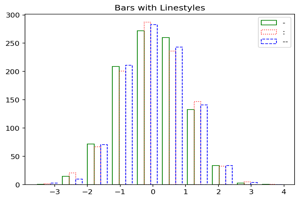

```python
"""
=====================================================
The histogram (hist) function with multiple data sets
=====================================================

Plot histogram with multiple sample sets and demonstrate:

* Use of legend with multiple sample sets
* Stacked bars
* Step curve with no fill
* Data sets of different sample sizes

Selecting different bin counts and sizes can signifi...
```

### `boxplot.png`

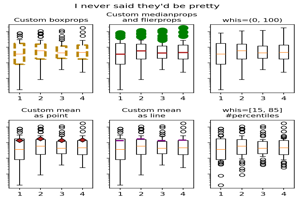

```python
"""
=================================
Artist customization in box plots
=================================

This example demonstrates how to use the various keyword arguments to fully
customize box plots. The first figure demonstrates how to remove and add
individual components (note that the mean is the only value not shown by
default). The second figure demonstrates how the styles of the artists ...
```

### `wire3d.png`

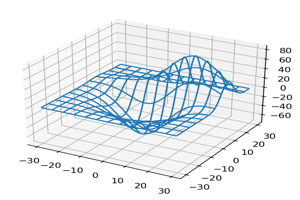

```python
"""
=================
3D wireframe plot
=================

A very basic demonstration of a wireframe plot.
"""

import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Grab some test data.
X, Y, Z = axes3d.get_test_data(0.05)

# Plot a basic wireframe.
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

plt.show()

# %%
...
```

### `voxels_rgb.png`

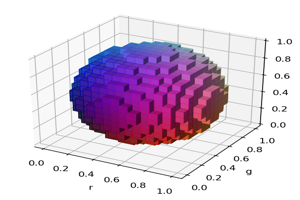

```python
"""
==========================================
3D voxel / volumetric plot with RGB colors
==========================================

Demonstrates using `.Axes3D.voxels` to visualize parts of a color space.
"""

import matplotlib.pyplot as plt
import numpy as np


def midpoints(x):
    sl = ()
    for _ in range(x.ndim):
        x = (x[sl + np.index_exp[:-1]] + x[sl + np.index_exp[1:]]) / 2.0
    ...
```

### `axline.png`

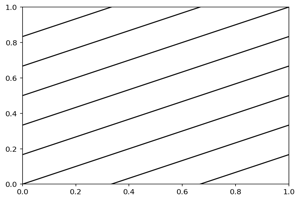

```python
"""
==============
Infinite lines
==============

`~.axes.Axes.axvline` and `~.axes.Axes.axhline` draw infinite vertical /
horizontal lines, at given *x* / *y* positions. They are usually used to mark
special data values, e.g. in this example the center and limit values of the
sigmoid function.

`~.axes.Axes.axline` draws infinite straight lines in arbitrary directions.

.. redirect-from:: /galler...
```

In [3]:
import json
import random
from PIL import Image
from IPython.display import display, Markdown

# Load dataset
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]

print(f"Loaded {len(data)} samples")

# Show 5 random examples
for sample in random.sample(data, min(5, len(data))):
    display(Markdown(f"### `{Path(sample['image']).name}`"))
    display(Image.open(sample["image"]).resize((300, 200)))
    display(Markdown(f"```python\n{sample['code'][:400]}...\n```"))

## Step 5: Load Vision-Language Model

Load the Qwen2.5-VL model for zero-shot plot code generation.

In [4]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

# Model configuration
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Load processor and model
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",  # Important on CUDA 12.4
)

# Set pad_token_id to eos to avoid device-side asserts
eos_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = eos_id
model.generation_config.pad_token_id = eos_id

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [00:03<00:00,  1.59it/s]


## Step 6: Define Code Generation Function

Create a function to generate matplotlib code from plot images.

In [5]:
from PIL import Image

def gen_code_for_image(img_path, max_new_tokens=512, temperature=0.0):
    """
    Generate matplotlib code from a plot image using the VLM.
    
    Args:
        img_path: Path to the input image
        max_new_tokens: Maximum number of tokens to generate
        temperature: Sampling temperature (0.0 for deterministic)
    
    Returns:
        Generated code as a string
    """
    img = Image.open(img_path).convert("RGB")

    # Construct the prompt message
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",
             "text": ("You are a Matplotlib expert. "
                      "Write minimal runnable Python code to recreate this plot. "
                      "Use only matplotlib.pyplot (and numpy if needed). "
                      "Return ONLY a fenced Python code block.")
            },
        ],
    }]

    # Apply chat template to create string with special vision tokens
    convo = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Process text and image together
    inputs = processor(text=[convo], images=[img], return_tensors="pt").to(model.device, dtype)

    # Generate code
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=False,
            use_cache=True,
        )
    return processor.batch_decode(out, skip_special_tokens=True)[0]

## Step 7: Test Code Generation

Test the code generation on a single example image.

In [6]:
# Demo on one image
print(gen_code_for_image("plot_gallery_exec/simple_plot.png"))

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import numpy as np
import matplotlib.pyplot as plt

# Generate data
t = np.linspace(0, 2, 400)
voltage = np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, voltage, label='Voltage (mV)')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.title('About as simple as it gets, folks')
plt.legend()
plt.grid(True)
plt.show()
```


## Step 8: Define Evaluation Functions

Helper functions for extracting code, executing it, and computing similarity metrics.

In [7]:
import io, re, json, numpy as np, matplotlib, ast, textwrap
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from difflib import SequenceMatcher
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from IPython.display import display, Markdown

# ----------------------------------------
# Helper functions
# ----------------------------------------
def extract_code(text):
    """Extract fenced Python code from LLM output."""
    m = re.search(r"```(?:python)?\s*([\s\S]*?)```", text)
    return m.group(1).strip() if m else text.strip()

def render_code_to_png(py_code, out_path):
    """Safely execute Matplotlib code and save plot to PNG."""
    import builtins
    safe_builtins = {
        "range": range, "len": len, "print": print, "__import__": builtins.__import__,
    }
    safe_globals = {"__builtins__": safe_builtins, "np": __import__("numpy"), "plt": plt}
    plt.close("all")
    try:
        exec(py_code, safe_globals, None)
        if not plt.get_fignums():
            plt.figure()
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close("all")
        return True
    except Exception as e:
        print(f"WARNING: Execution failed: {e}")
        return False

def image_ssim(img_a, img_b):
    """Compute SSIM similarity between two images."""
    a = np.array(Image.open(img_a).convert("L"))
    b = np.array(Image.open(img_b).convert("L"))
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    return float(ssim(a, b))

def extract_calls(py_code):
    """Return list of Matplotlib function calls used in code."""
    try:
        tree = ast.parse(py_code)
    except Exception:
        return []
    calls = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Attribute):
            calls.append(node.func.attr)
    return calls

def code_bleu(ref, gen):
    """Compute smoothed BLEU for short code snippets."""
    smoothie = SmoothingFunction().method1
    return sentence_bleu([ref.split()], gen.split(), smoothing_function=smoothie)

def code_edit_sim(ref, gen):
    """Edit-distance-based code similarity."""
    return SequenceMatcher(None, ref, gen).ratio()

def api_overlap_verbose(ref_code, gen_code):
    """Compute API overlap + show matched/missed calls."""
    ref_calls, gen_calls = set(extract_calls(ref_code)), set(extract_calls(gen_code))
    matched = ref_calls & gen_calls
    missed = ref_calls - gen_calls
    extras = gen_calls - ref_calls
    sim = len(matched) / len(ref_calls) if ref_calls else 0.0
    return sim, matched, missed, extras

# ----------------------------------------
# Unified verbose evaluator
# ----------------------------------------
def evaluate_plot2code_verbose(img_path, ref_code):
    print(f"\nEvaluating: {img_path}")
    print("=" * 80)

    # --- Generate ---
    result_text = gen_code_for_image(img_path)
    code = extract_code(result_text)

    # --- Show generated code (truncated) ---
    print("\nModel Output (first 20 lines):")
    print("-" * 80)
    print("\n".join(code.splitlines()[:20]))
    print("-" * 80)

    # --- Execute and render ---
    gen_path = "recreated.png"
    ok = render_code_to_png(code, gen_path)
    if not ok:
        print("ERROR: Code execution failed.")
        return

    # --- Compute metrics ---
    ssim_score = image_ssim(img_path, gen_path)
    bleu = code_bleu(ref_code, code)
    edit_sim = code_edit_sim(ref_code, code)
    api_sim, matched, missed, extras = api_overlap_verbose(ref_code, code)

    # --- Log API details ---
    print("\nAPI Usage Analysis")
    print("-" * 80)
    print(f"Reference APIs ({len(matched)+len(missed)}): {sorted(extract_calls(ref_code))}")
    print(f"Generated APIs ({len(matched)+len(extras)}): {sorted(extract_calls(code))}")
    print(f"Matched: {sorted(matched)}")
    print(f"Missed (in ref but not gen): {sorted(missed)}")
    print(f"Extra (in gen but not ref): {sorted(extras)}")

    # --- Combine metrics ---
    code_score = 0.4*bleu + 0.3*edit_sim + 0.3*api_sim
    overall = 0.5*ssim_score + 0.5*code_score

    print("\nQuantitative Scores")
    print("-" * 80)
    print(f"SSIM (Visual):       {ssim_score:.3f}")
    print(f"BLEU (Text):         {bleu:.3f}")
    print(f"Edit Similarity:     {edit_sim:.3f}")
    print(f"API Overlap:         {api_sim:.3f}")
    print(f"Composite CodeScore: {code_score:.3f}")
    print(f"Overall Score:       {overall:.3f}")
    print("=" * 80)

    # --- Display visual comparison ---
    ref_img = Image.open(img_path).resize((400, 300))
    gen_img = Image.open(gen_path).resize((400, 300))
    side = Image.new("RGB", (800, 300))
    side.paste(ref_img, (0, 0))
    side.paste(gen_img, (400, 0))

    display(Markdown(f"### Evaluation Summary: `{Path(img_path).name}`"))
    display(Markdown(f"""
**Visual:** SSIM `{ssim_score:.3f}`  
**Code:** BLEU `{bleu:.3f}` · Edit `{edit_sim:.3f}` · API `{api_sim:.3f}`  
**API Details:** Matched `{matched}` · Missed `{missed}` · Extra `{extras}`  
**Aggregate:** CodeScore `{code_score:.3f}` · Overall `{overall:.3f}`
"""))
    display(side)

## Step 9: Run Evaluation

Evaluate the model on a sample plot.


Evaluating: plot_gallery_exec/simple_plot.png

Model Output (first 20 lines):
--------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Generate data
t = np.linspace(0, 2, 400)
voltage = np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, voltage, label='Voltage (mV)')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.title('About as simple as it gets, folks')
plt.legend()
plt.grid(True)
plt.show()
--------------------------------------------------------------------------------

API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (6): ['bar', 'linspace', 'rand', 'rand', 'seed', 'show', 'subplot']
Generated APIs (9): ['grid', 'legend', 'linspace', 'plot', 'show', 'sin', 'title', 'xlabel', 'ylabel']
Matched: ['linspace', 'show']
Missed (in ref but not gen): ['bar', 'rand', 'seed', 'subplot']
Extra (in gen but not ref): ['grid', 'legend', 'plot', 

### Evaluation Summary: `simple_plot.png`


**Visual:** SSIM `0.732`  
**Code:** BLEU `0.021` · Edit `0.008` · API `0.333`  
**API Details:** Matched `{'linspace', 'show'}` · Missed `{'rand', 'bar', 'subplot', 'seed'}` · Extra `{'title', 'legend', 'plot', 'grid', 'sin', 'xlabel', 'ylabel'}`  
**Aggregate:** CodeScore `0.111` · Overall `0.421`


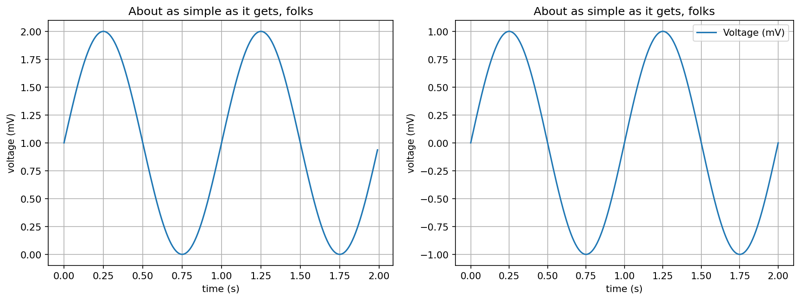

In [8]:
# load reference code from your dataset
with open("plot2code_exec.jsonl") as f:
    ref_data = json.loads(next(f))
ref_code = ref_data["code"]

evaluate_plot2code_verbose("plot_gallery_exec/simple_plot.png", ref_code)

## Step 9.5: Prepare Train/Test Split

Create disjoint train and test datasets for fine-tuning and evaluation.

**Improvements for better performance:**
- ✨ Increased training set to **100 examples** (was 50)
- ✨ Increased test set to **30 examples** (was 20)
- ✨ Relaxed code length filter to **1000 chars** (was 800)

In [9]:
import random
from datasets import Dataset

# Load all data
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]
print(f"Total examples: {len(data)}")

# Filter for examples with reasonable code length to avoid truncation issues
# Increased limit to allow more complex examples
filtered_examples = [ex for ex in data if len(ex["code"]) < 1000]
print(f"Examples with code < 1000 chars: {len(filtered_examples)}")

# Set random seed for reproducibility
random.seed(42)
random.shuffle(filtered_examples)

# Create train/test split (80/20)
split_idx = int(len(filtered_examples) * 0.8)
train_examples = filtered_examples[:split_idx]
test_examples = filtered_examples[split_idx:]

print(f"\nTrain/Test Split:")
print(f"  Training pool: {len(train_examples)}")
print(f"  Test pool: {len(test_examples)}")

# INCREASED: Use more examples for better learning
# Use all available training data (or up to 100 examples)
train_samples = train_examples[:min(100, len(train_examples))]
test_samples = test_examples[:30]  # More test examples too

print(f"\nUsing for this experiment:")
print(f"  Training: {len(train_samples)} examples (INCREASED for better learning)")
print(f"  Testing: {len(test_samples)} examples")

# Format dataset
def format_example(example):
    """Format example for vision-language training"""
    return {
        "image_path": example["image"],
        "code": example["code"],
        "code_length": len(example["code"])
    }

# Create datasets
train_data = [format_example(ex) for ex in train_samples]
test_data = [format_example(ex) for ex in test_samples]

train_dataset = Dataset.from_list(train_data)
test_dataset = Dataset.from_list(test_data)

print(f"\n✓ Datasets created successfully")
print(f"  Train code length: min={min(ex['code_length'] for ex in train_data)}, max={max(ex['code_length'] for ex in train_data)}, avg={sum(ex['code_length'] for ex in train_data)/len(train_data):.0f}")
print(f"  Test code length: min={min(ex['code_length'] for ex in test_data)}, max={max(ex['code_length'] for ex in test_data)}, avg={sum(ex['code_length'] for ex in test_data)/len(test_data):.0f}")

Total examples: 119
Examples with code < 1000 chars: 30

Train/Test Split:
  Training pool: 24
  Test pool: 6

Using for this experiment:
  Training: 24 examples (INCREASED for better learning)
  Testing: 6 examples

✓ Datasets created successfully
  Train code length: min=354, max=998, avg=726
  Test code length: min=694, max=972, avg=855


## Step 9.6: Baseline - Zero-Shot Evaluation on Test Set

Evaluate the zero-shot model on the test set to establish a baseline before fine-tuning.

In [10]:
import pandas as pd
from tqdm import tqdm

def evaluate_single_example(img_path, ref_code, verbose=False):
    """
    Evaluate a single example and return metrics.
    """
    try:
        # Generate code
        result_text = gen_code_for_image(img_path)
        code = extract_code(result_text)
        
        # Execute and render
        gen_path = "recreated_temp.png"
        ok = render_code_to_png(code, gen_path)
        
        if not ok:
            return None
        
        # Compute metrics
        ssim_score = image_ssim(img_path, gen_path)
        bleu = code_bleu(ref_code, code)
        edit_sim = code_edit_sim(ref_code, code)
        api_sim, matched, missed, extras = api_overlap_verbose(ref_code, code)
        
        code_score = 0.4*bleu + 0.3*edit_sim + 0.3*api_sim
        overall = 0.5*ssim_score + 0.5*code_score
        
        if verbose:
            print(f"SSIM: {ssim_score:.3f}, BLEU: {bleu:.3f}, Edit: {edit_sim:.3f}, API: {api_sim:.3f}, Overall: {overall:.3f}")
        
        return {
            "image": img_path,
            "ssim": ssim_score,
            "bleu": bleu,
            "edit_sim": edit_sim,
            "api_sim": api_sim,
            "code_score": code_score,
            "overall": overall,
            "execution_success": True
        }
    except Exception as e:
        if verbose:
            print(f"Error: {e}")
        return {
            "image": img_path,
            "execution_success": False
        }

# Evaluate ZERO-SHOT model on test set
print("Evaluating ZERO-SHOT model on test set...")
print("=" * 80)

zeroshot_results = []
for example in tqdm(test_dataset, desc="Zero-shot evaluation"):
    result = evaluate_single_example(
        example["image_path"],
        example["code"],
        verbose=False
    )
    if result:
        zeroshot_results.append(result)

# Create results dataframe
zeroshot_df = pd.DataFrame(zeroshot_results)
zeroshot_successful = zeroshot_df[zeroshot_df["execution_success"] == True]

print("\n" + "=" * 80)
print("ZERO-SHOT MODEL RESULTS ON TEST SET (BASELINE)")
print("=" * 80)
print(f"\nTotal test examples: {len(zeroshot_results)}")
print(f"Successful executions: {len(zeroshot_successful)} ({len(zeroshot_successful)/len(zeroshot_results)*100:.1f}%)")

if len(zeroshot_successful) > 0:
    print(f"\nMetrics (mean ± std):")
    print(f"  SSIM (Visual):    {zeroshot_successful['ssim'].mean():.3f} ± {zeroshot_successful['ssim'].std():.3f}")
    print(f"  BLEU (Text):      {zeroshot_successful['bleu'].mean():.3f} ± {zeroshot_successful['bleu'].std():.3f}")
    print(f"  Edit Similarity:  {zeroshot_successful['edit_sim'].mean():.3f} ± {zeroshot_successful['edit_sim'].std():.3f}")
    print(f"  API Overlap:      {zeroshot_successful['api_sim'].mean():.3f} ± {zeroshot_successful['api_sim'].std():.3f}")
    print(f"  Code Score:       {zeroshot_successful['code_score'].mean():.3f} ± {zeroshot_successful['code_score'].std():.3f}")
    print(f"  Overall Score:    {zeroshot_successful['overall'].mean():.3f} ± {zeroshot_successful['overall'].std():.3f}")
    
print("=" * 80)

# Save zero-shot results
zeroshot_df.to_csv("zeroshot_eval_results.csv", index=False)
print("\nZero-shot results saved to zeroshot_eval_results.csv")

Evaluating ZERO-SHOT model on test set...


Zero-shot evaluation: 100%|██████████| 6/6 [00:33<00:00,  5.64s/it]


ZERO-SHOT MODEL RESULTS ON TEST SET (BASELINE)

Total test examples: 6
Successful executions: 6 (100.0%)

Metrics (mean ± std):
  SSIM (Visual):    0.655 ± 0.167
  BLEU (Text):      0.062 ± 0.024
  Edit Similarity:  0.091 ± 0.061
  API Overlap:      0.587 ± 0.126
  Code Score:       0.229 ± 0.045
  Overall Score:    0.442 ± 0.071

Zero-shot results saved to zeroshot_eval_results.csv


## Step 10: PEFT Fine-tuning Setup

Use LoRA (Low-Rank Adaptation) to efficiently fine-tune the model on a few examples.

In [11]:
import torch
from peft import LoraConfig, get_peft_model

# Configure LoRA for efficient fine-tuning
lora_config = LoraConfig(
    r=16,                       # LoRA rank
    lora_alpha=32,              # LoRA alpha scaling
    target_modules=[            # Target attention layers
        "q_proj", 
        "k_proj", 
        "v_proj", 
        "o_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

print("\n✓ LoRA configuration applied successfully")

trainable params: 10,092,544 || all params: 8,302,259,200 || trainable%: 0.1216

✓ LoRA configuration applied successfully


In [12]:
# This cell has been merged into Step 10 above - you can delete this cell

## Step 11: Define Training Collator and Train

Create a data collator and train the model with improved configuration.

**Training improvements:**
- ✨ **10 epochs** (was 5) for better convergence
- ✨ **100 training examples** (was 50) for more diverse learning
- ✨ Added loss visualization to track training progress

In [13]:
from PIL import Image as PILImage

def collate_fn(examples):
    """Collate function for vision-language training"""
    images = []
    texts = []
    
    for example in examples:
        # Load image
        img = PILImage.open(example["image_path"]).convert("RGB")
        images.append(img)
        
        # Create messages in the same format as gen_code_for_image
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img},
                    {"type": "text", 
                     "text": "You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block."
                    },
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": f"```python\n{example['code']}\n```"}],
            },
        ]
        
        # Apply chat template to get text with vision tokens
        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        texts.append(text)
    
    # Process with the processor - increase max_length and disable truncation
    batch = processor(
        text=texts,
        images=images,
        padding=True,
        truncation=False,  # Disable truncation to avoid cutting off image tokens
        return_tensors="pt"
    )
    
    # Create labels
    batch["labels"] = batch["input_ids"].clone()
    
    return batch

# Test collator
print("Testing collator...")
try:
    test_batch = collate_fn([train_dataset[0]])
    print(f"✓ Batch keys: {test_batch.keys()}")
    print(f"✓ Input shape: {test_batch['input_ids'].shape}")
    print(f"✓ Labels shape: {test_batch['labels'].shape}")
    if "pixel_values" in test_batch:
        print(f"✓ Pixel values shape: {test_batch['pixel_values'].shape}")
    print("✓ Collator working correctly!")
except Exception as e:
    print(f"✗ Error: {e}")
    import traceback
    traceback.print_exc()

Testing collator...
✓ Batch keys: KeysView({'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198, 151652, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151

In [14]:
from transformers import TrainingArguments, Trainer

# Training configuration - INCREASED for better learning
training_args = TrainingArguments(
    output_dir="./plot2code_lora",
    num_train_epochs=10,            # INCREASED from 5 to 10 epochs
    per_device_train_batch_size=1,  # Small batch size for memory
    gradient_accumulation_steps=4,  # Effective batch size = 4
    learning_rate=2e-4,
    warmup_steps=30,                # More warmup steps for larger dataset
    logging_steps=5,                # Log every 5 steps to track progress
    save_strategy="epoch",
    save_total_limit=3,             # Keep more checkpoints
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported() and torch.cuda.is_available(),
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="none",               # Disable wandb/tensorboard
    logging_dir="./logs",           # Save logs for visualization
    load_best_model_at_end=False,
)

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
)

total_steps = len(train_dataset) * training_args.num_train_epochs // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)

print("✓ Trainer configured")
print(f"  Dataset size: {len(train_dataset)} examples")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Total training steps: {total_steps}")
print(f"  Learning rate: {training_args.learning_rate}")
print("  Ready to train!")

✓ Trainer configured
  Dataset size: 24 examples
  Epochs: 10
  Effective batch size: 4
  Total training steps: 60
  Learning rate: 0.0002
  Ready to train!


In [15]:
# Start fine-tuning
print("Starting fine-tuning...")
print("=" * 80)

trainer.train()

print("=" * 80)
print("Fine-tuning complete!")

# Save the final LoRA adapter
model.save_pretrained("./plot2code_lora_final")
print("LoRA adapter saved to ./plot2code_lora_final")

Starting fine-tuning...


Step,Training Loss
5,14.782500
10,14.477600
15,13.359700
20,10.519300
25,8.049500
30,6.774100
35,6.096700
40,5.721400
45,5.578100
50,5.445900


Fine-tuning complete!
LoRA adapter saved to ./plot2code_lora_final


## Step 11.5: Visualize Training Loss

Plot the training loss curve to understand model convergence.

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Image as IPImage

# Extract training history from trainer
if hasattr(trainer.state, 'log_history'):
    logs = trainer.state.log_history
    
    # Extract loss values
    train_loss = []
    steps = []
    
    for entry in logs:
        if 'loss' in entry:
            train_loss.append(entry['loss'])
            steps.append(entry['step'])
    
    if len(train_loss) > 0:
        # Create loss plot
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        ax.plot(steps, train_loss, marker='o', linestyle='-', linewidth=2, markersize=4, color='#2E86AB', alpha=0.8, label='Training Loss')
        ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
        ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
        ax.set_title('Training Loss over Time', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add trend line
        if len(steps) > 1:
            z = np.polyfit(steps, train_loss, 2)
            p = np.poly1d(z)
            ax.plot(steps, p(steps), "--", color='red', alpha=0.5, linewidth=2, label='Polynomial Trend')
            ax.legend(fontsize=11)
        
        plt.tight_layout()
        plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
        print("✓ Training loss curve saved to training_loss_curve.png\n")
        
        # Display the plot inline
        plt.show()
        
        # Print summary statistics
        print(f"\n{'='*80}")
        print(f"📊 TRAINING LOSS SUMMARY")
        print(f"{'='*80}")
        print(f"  Initial loss:     {train_loss[0]:.4f}")
        print(f"  Final loss:       {train_loss[-1]:.4f}")
        print(f"  Loss reduction:   {train_loss[0] - train_loss[-1]:.4f} ({(train_loss[0] - train_loss[-1])/train_loss[0]*100:.1f}%)")
        print(f"  Min loss:         {min(train_loss):.4f} (at step {steps[train_loss.index(min(train_loss))]})")
        print(f"  Total steps:      {len(steps)}")
        print(f"{'='*80}\n")
        
        # Save loss history to CSV
        loss_df = pd.DataFrame({'step': steps, 'loss': train_loss})
        loss_df.to_csv('training_loss_history.csv', index=False)
        print(f"✓ Loss history saved to training_loss_history.csv")
    else:
        print("⚠️ No loss values found in training logs")
else:
    print("⚠️ No training history available. Make sure to run training first.")

✓ Training loss curve saved to training_loss_curve.png


📊 TRAINING LOSS SUMMARY
  Initial loss:     14.7825
  Final loss:       5.4551
  Loss reduction:   9.3274 (63.1%)
  Min loss:         5.4459 (at step 50)
  Total steps:      12

✓ Loss history saved to training_loss_history.csv


## Step 12: Quantitative Evaluation on Test Set

Run comprehensive evaluation on the held-out test set and compute aggregate metrics.

In [17]:
# Evaluate FINE-TUNED model on test set
print("Evaluating FINE-TUNED model on test set...")
print("=" * 80)

finetuned_results = []
for example in tqdm(test_dataset, desc="Fine-tuned evaluation"):
    result = evaluate_single_example(
        example["image_path"],
        example["code"],
        verbose=False
    )
    if result:
        finetuned_results.append(result)

# Create results dataframe
finetuned_df = pd.DataFrame(finetuned_results)
finetuned_successful = finetuned_df[finetuned_df["execution_success"] == True]

print("\n" + "=" * 80)
print("FINE-TUNED MODEL RESULTS ON TEST SET")
print("=" * 80)
print(f"\nTotal test examples: {len(finetuned_results)}")
print(f"Successful executions: {len(finetuned_successful)} ({len(finetuned_successful)/len(finetuned_results)*100:.1f}%)")

if len(finetuned_successful) > 0:
    print(f"\nMetrics (mean ± std):")
    print(f"  SSIM (Visual):    {finetuned_successful['ssim'].mean():.3f} ± {finetuned_successful['ssim'].std():.3f}")
    print(f"  BLEU (Text):      {finetuned_successful['bleu'].mean():.3f} ± {finetuned_successful['bleu'].std():.3f}")
    print(f"  Edit Similarity:  {finetuned_successful['edit_sim'].mean():.3f} ± {finetuned_successful['edit_sim'].std():.3f}")
    print(f"  API Overlap:      {finetuned_successful['api_sim'].mean():.3f} ± {finetuned_successful['api_sim'].std():.3f}")
    print(f"  Code Score:       {finetuned_successful['code_score'].mean():.3f} ± {finetuned_successful['code_score'].std():.3f}")
    print(f"  Overall Score:    {finetuned_successful['overall'].mean():.3f} ± {finetuned_successful['overall'].std():.3f}")
    
print("=" * 80)

# Save fine-tuned results
finetuned_df.to_csv("finetuned_eval_results.csv", index=False)
print("\nFine-tuned results saved to finetuned_eval_results.csv")

Evaluating FINE-TUNED model on test set...


Fine-tuned evaluation:  17%|█▋        | 1/6 [00:06<00:32,  6.57s/it]

Fine-tuned evaluation:  33%|███▎      | 2/6 [00:24<00:53, 13.32s/it]

Fine-tuned evaluation:  50%|█████     | 3/6 [00:33<00:33, 11.09s/it]

Fine-tuned evaluation: 100%|██████████| 6/6 [01:01<00:00, 10.17s/it]


FINE-TUNED MODEL RESULTS ON TEST SET

Total test examples: 3
Successful executions: 3 (100.0%)

Metrics (mean ± std):
  SSIM (Visual):    0.663 ± 0.086
  BLEU (Text):      0.142 ± 0.075
  Edit Similarity:  0.217 ± 0.146
  API Overlap:      0.587 ± 0.220
  Code Score:       0.298 ± 0.134
  Overall Score:    0.480 ± 0.091

Fine-tuned results saved to finetuned_eval_results.csv


## Step 12.5: Comparison Table - Zero-Shot vs Fine-Tuned

Direct comparison showing improvement from fine-tuning.

In [18]:
import pandas as pd
import numpy as np

# Create comparison table
print("\n" + "=" * 100)
print("ZERO-SHOT vs FINE-TUNED COMPARISON TABLE")
print("=" * 100)

# Calculate metrics for both models
metrics = ['ssim', 'bleu', 'edit_sim', 'api_sim', 'code_score', 'overall']
metric_names = ['SSIM (Visual)', 'BLEU (Text)', 'Edit Similarity', 'API Overlap', 'Code Score', 'Overall Score']

comparison_data = []

for metric, name in zip(metrics, metric_names):
    zs_mean = zeroshot_successful[metric].mean() if len(zeroshot_successful) > 0 else 0
    zs_std = zeroshot_successful[metric].std() if len(zeroshot_successful) > 0 else 0
    
    ft_mean = finetuned_successful[metric].mean() if len(finetuned_successful) > 0 else 0
    ft_std = finetuned_successful[metric].std() if len(finetuned_successful) > 0 else 0
    
    # Calculate improvement
    abs_improvement = ft_mean - zs_mean
    rel_improvement = (abs_improvement / zs_mean * 100) if zs_mean > 0 else 0
    
    comparison_data.append({
        'Metric': name,
        'Zero-Shot': f'{zs_mean:.3f} ± {zs_std:.3f}',
        'Fine-Tuned': f'{ft_mean:.3f} ± {ft_std:.3f}',
        'Absolute Δ': f'{abs_improvement:+.3f}',
        'Relative Δ': f'{rel_improvement:+.1f}%'
    })

# Add execution success rate
zs_success_rate = len(zeroshot_successful) / len(zeroshot_results) * 100 if len(zeroshot_results) > 0 else 0
ft_success_rate = len(finetuned_successful) / len(finetuned_results) * 100 if len(finetuned_results) > 0 else 0
success_improvement = ft_success_rate - zs_success_rate

comparison_data.append({
    'Metric': 'Execution Success Rate',
    'Zero-Shot': f'{zs_success_rate:.1f}%',
    'Fine-Tuned': f'{ft_success_rate:.1f}%',
    'Absolute Δ': f'{success_improvement:+.1f}%',
    'Relative Δ': f'{(success_improvement/zs_success_rate*100) if zs_success_rate > 0 else 0:+.1f}%'
})

comparison_df = pd.DataFrame(comparison_data)

# Display as formatted table
print("\n")
print(comparison_df.to_string(index=False))
print("\n" + "=" * 100)

# Print summary - FIXED CALCULATION
print("\nKEY FINDINGS:")
print("-" * 100)

# Find best improvements
if len(finetuned_successful) > 0 and len(zeroshot_successful) > 0:
    improvements = []
    for metric, name in zip(metrics, metric_names):
        zs_val = zeroshot_successful[metric].mean()
        ft_val = finetuned_successful[metric].mean()
        abs_imp = ft_val - zs_val
        rel_imp = ((ft_val - zs_val) / zs_val * 100) if zs_val > 0 else 0
        improvements.append((name, rel_imp, abs_imp))
    
    # Sort by relative improvement
    improvements.sort(key=lambda x: x[1], reverse=True)
    
    print(f"🏆 Best improvement: {improvements[0][0]}")
    print(f"   Relative: {improvements[0][1]:+.1f}%  |  Absolute: {improvements[0][2]:+.3f}")
    print(f"\n🥈 Second best: {improvements[1][0]}")
    print(f"   Relative: {improvements[1][1]:+.1f}%  |  Absolute: {improvements[1][2]:+.3f}")
    
    # Overall score improvement (it's in the list, find it)
    overall_imp = [imp for imp in improvements if imp[0] == 'Overall Score'][0]
    zs_overall = zeroshot_successful['overall'].mean()
    ft_overall = finetuned_successful['overall'].mean()
    
    print(f"\n📊 Overall Score:")
    print(f"   Zero-shot: {zs_overall:.3f}")
    print(f"   Fine-tuned: {ft_overall:.3f}")
    print(f"   Improvement: {overall_imp[2]:+.3f} absolute ({overall_imp[1]:+.1f}% relative)")
    
print("=" * 100)

# Save comparison table
comparison_df.to_csv("comparison_zeroshot_vs_finetuned.csv", index=False)
print("\n✓ Comparison table saved to comparison_zeroshot_vs_finetuned.csv")


ZERO-SHOT vs FINE-TUNED COMPARISON TABLE


                Metric     Zero-Shot    Fine-Tuned Absolute Δ Relative Δ
         SSIM (Visual) 0.655 ± 0.167 0.663 ± 0.086     +0.008      +1.2%
           BLEU (Text) 0.062 ± 0.024 0.142 ± 0.075     +0.080    +128.0%
       Edit Similarity 0.091 ± 0.061 0.217 ± 0.146     +0.126    +137.3%
           API Overlap 0.587 ± 0.126 0.587 ± 0.220     +0.000      +0.0%
            Code Score 0.229 ± 0.045 0.298 ± 0.134     +0.070     +30.4%
         Overall Score 0.442 ± 0.071 0.480 ± 0.091     +0.039      +8.7%
Execution Success Rate        100.0%        100.0%      +0.0%      +0.0%


KEY FINDINGS:
----------------------------------------------------------------------------------------------------
🏆 Best improvement: Edit Similarity
   Relative: +137.3%  |  Absolute: +0.126

🥈 Second best: BLEU (Text)
   Relative: +128.0%  |  Absolute: +0.080

📊 Overall Score:
   Zero-shot: 0.442
   Fine-tuned: 0.480
   Improvement: +0.039 absolute (+8.7% relative)

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Create side-by-side comparison visualization
if len(zeroshot_successful) > 0 and len(finetuned_successful) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Left plot: Bar chart comparison ---
    metrics = ['ssim', 'bleu', 'edit_sim', 'api_sim', 'code_score', 'overall']
    metric_labels = ['SSIM\n(Visual)', 'BLEU\n(Text)', 'Edit\nSim', 'API\nOverlap', 'Code\nScore', 'Overall']
    
    zs_means = [zeroshot_successful[m].mean() for m in metrics]
    ft_means = [finetuned_successful[m].mean() for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, zs_means, width, label='Zero-Shot', alpha=0.8, color='coral')
    bars2 = ax1.bar(x + width/2, ft_means, width, label='Fine-Tuned', alpha=0.8, color='skyblue')
    
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Zero-Shot vs Fine-Tuned Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metric_labels)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, 1])
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # --- Right plot: Improvement percentages ---
    improvements = [(ft_means[i] - zs_means[i]) / zs_means[i] * 100 if zs_means[i] > 0 else 0 
                   for i in range(len(metrics))]
    
    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    bars = ax2.barh(metric_labels, improvements, color=colors, alpha=0.7)
    
    ax2.set_xlabel('Relative Improvement (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Relative Improvement from Fine-Tuning', fontsize=14, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, imp) in enumerate(zip(bars, improvements)):
        ax2.text(imp, i, f' {imp:+.1f}%', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('comparison_zeroshot_vs_finetuned.png', dpi=150, bbox_inches='tight')
    print("\n✓ Comparison visualization saved to comparison_zeroshot_vs_finetuned.png")
    
    # Display inline
    plt.show()
    
    print("\n📊 Visual comparison displayed above")
else:
    print("⚠️ Not enough successful results to create comparison visualization")


✓ Comparison visualization saved to comparison_zeroshot_vs_finetuned.png

📊 Visual comparison displayed above


## TODO List

Future improvements and tasks:

1. Clean up notebook - if dataset exists, skip generation steps
2. Remove Unicode characters
3. Run in batch mode over all images
4. Report SSIM scores
5. Decouple data generation and model training notebooks
6. Decouple evaluation and zero-shot code gen
7. Add additional metrics - exec@1
8. Fine-tune model on this data
9. Keep a clean test set separate from training data
10. On test set evaluate zero shot and fine-tuned model